# (노트) 인자분석 - FIFA 축구선수 능력치 
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [응용통계]

### About this doc 

`-` 인자분석 예제: FIFA 축구선수 능력치 

`-` 데이터 출처: https://www.kaggle.com/bryanb/fifa-player-stats-database?select=FIFA21_official_data.csv

`-` 분석툴: `FactoMineR`

Lê, S., Josse, J., & Husson, F. (2008). FactoMineR: an R package for multivariate analysis. Journal of statistical software, 25(1), 1-18.

### Data

In [1]:
library(tidyverse)
data=read_csv("2021-07-01-FIFA21_official_data2.csv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

✔ ggplot2 3.3.3     ✔ purrr   0.3.4
✔ tibble  3.0.6     ✔ dplyr   1.0.6
✔ tidyr   1.1.2     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


── Column specification ────────────────────────────────────────────────────────
cols(
  .default = col_double(),
  Name = col_character(),
  Photo = col_character(),
  Nationality = col_character(),
  Flag = col_character(),
  Club = col_character(),
  `Club Logo` = col_character(),
  Value = col_character(),
  Wage = col_character(),
  `Preferred Foot` = col_character(),
  `Work Rate` = col_character(),
  `Body Type` = col_character(),
  `Real Face` = col_character(),
  Position = col_character(),
  Joined = col_character(),
  `Loaned From` = col_character(),
  `Contract Valid Until` = col_character(),
 

In [2]:
names(data)

[1] "ID"                       "Name"                    
 [3] "Age"                      "Photo"                   
 [5] "Nationality"              "Flag"                    
 [7] "Overall"                  "Potential"               
 [9] "Club"                     "Club Logo"               
[11] "Value"                    "Wage"                    
[13] "Special"                  "Preferred Foot"          
[15] "International Reputation" "Weak Foot"               
[17] "Skill Moves"              "Work Rate"               
[19] "Body Type"                "Real Face"               
[21] "Position"                 "Jersey Number"           
[23] "Joined"                   "Loaned From"             
[25] "Contract Valid Until"     "Height"                  
[27] "Weight"                   "Crossing"                
[29] "Finishing"                "HeadingAccuracy"         
[31] "ShortPassing"             "Volleys"                 
[33] "Dribbling"                "Curve"                   
[35] "FKAccuracy"               "LongPassing"             
[37] "BallControl"              "Acceleration"            
[39] "SprintSpeed"              "Agility"                 
[41] "Reactions"                "Balance"                 
[43] "ShotPower"                "Jumping"                 
[45] "Stamina"                  "Strength"                
[47] "LongShots"                "Aggression"              
[49] "Interceptions"            "Positioning"             
[51] "Vision"                   "Penalties"               
[53] "Composure"                "Marking"                 
[55] "StandingTackle"           "SlidingTackle"           
[57] "GKDiving"                 "GKHandling"              
[59] "GKKicking"                "GKPositioning"           
[61] "GKReflexes"               "Best Position"           
[63] "Best Overall Rating"      "Release Clause"          
[65] "DefensiveAwareness"

In [3]:
dat=data %>% 
select('Name','Club','Best Position','Crossing',
       'Finishing','HeadingAccuracy','ShortPassing','Volleys',
       'Dribbling','Curve','FKAccuracy','LongPassing',
       'BallControl','Acceleration','SprintSpeed','Agility',
       'Reactions','Balance','ShotPower','Jumping',
       'Stamina','Strength','LongShots','Aggression',
       'Interceptions','Positioning','Vision','Penalties',
       'Composure','StandingTackle','SlidingTackle','GKDiving',
       'GKHandling','GKKicking','GKPositioning','GKReflexes') 

In [4]:
dat=na.omit(dat)

In [48]:
#write_csv(dat,'2021-07-01-fifa.csv')
fifa_dat=read_csv('2021-07-01-fifa.csv')


── Column specification ────────────────────────────────────────────────────────
cols(
  .default = col_double(),
  Name = col_character(),
  Club = col_character(),
  `Best Position` = col_character()
)
ℹ Use `spec()` for the full column specifications.




In [49]:
fifa <- fifa_dat[,-c(1,2,3)]
library(psych)

In [51]:
fifa_factor=principal(fifa,rotate='none')

### 고유값 

In [52]:
fifa_factor$values

[1] 17.84467030  4.55147522  2.96130477  1.79714145  1.37142758  0.60278721
 [7]  0.44238702  0.33852371  0.31377110  0.28524298  0.25894187  0.23848768
[13]  0.20441742  0.19453095  0.18907157  0.17170604  0.15460276  0.13115941
[19]  0.12809625  0.11872200  0.10300533  0.08997813  0.07707273  0.06472139
[25]  0.06213167  0.06021389  0.05633152  0.03809145  0.03443239  0.03261776
[31]  0.03218139  0.02838842  0.02236665

`-` 5번째 인자까지 고유값이 1이상인 것을 알 수 있다. 

### 스크리 그림

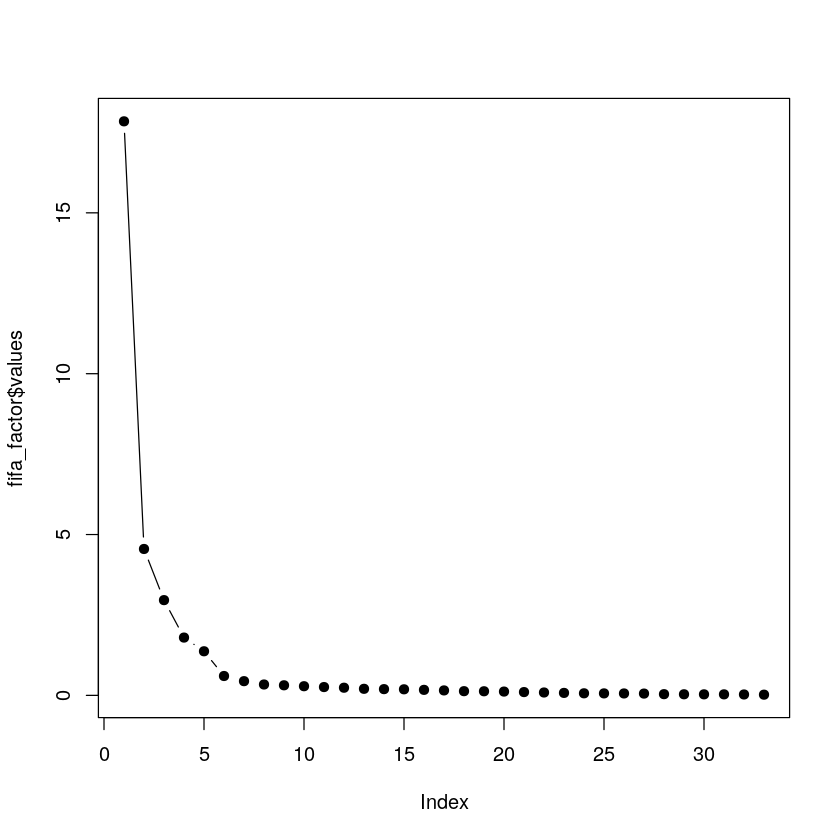

In [53]:
plot(fifa_factor$values,type='b',pch=19)

`-` 유효한 인자수는 5개정도로 볼 수 있다. 

### 인자회전

`-` 본 예제에서는 직교회전의 varimax을 사용하였다. 

In [99]:
fifa_varimax = principal(X,nfactors=5,rotate="varimax")
fifa_varimax

Principal Components Analysis
Call: principal(r = X, nfactors = 5, rotate = "varimax")
Standardized loadings (pattern matrix) based upon correlation matrix
                  RC1   RC3   RC2   RC4   RC5   h2    u2 com
Crossing         0.64  0.31  0.35  0.44 -0.08 0.83 0.170 3.0
Finishing        0.79  0.42 -0.22  0.26  0.08 0.92 0.078 2.0
HeadingAccuracy  0.31  0.64  0.33 -0.08  0.50 0.87 0.126 3.0
ShortPassing     0.68  0.38  0.47  0.24  0.07 0.89 0.107 2.8
Volleys          0.82  0.39 -0.11  0.21  0.09 0.88 0.118 1.7
Dribbling        0.69  0.47  0.17  0.44  0.01 0.93 0.074 2.7
Curve            0.79  0.29  0.17  0.32 -0.08 0.85 0.147 1.8
FKAccuracy       0.79  0.25  0.20  0.20 -0.14 0.78 0.218 1.6
LongPassing      0.64  0.19  0.60  0.17 -0.04 0.84 0.157 2.3
BallControl      0.70  0.48  0.28  0.34  0.08 0.93 0.073 2.7
Acceleration     0.28  0.33  0.00  0.83  0.09 0.89 0.106 1.6
SprintSpeed      0.25  0.36  0.00  0.78  0.18 0.84 0.159 1.8
Agility          0.46  0.19  0.04  0.79 -0.02 0.87 

#### h2, u2

`-` h2는 각 변수들이 유의한 다섯개의 인자 RC1,...,RC5에 의하여 설명되어지는 부분의 비율인 공통성을 나타내며, 위의 인자부하값을 이용하여 다음과 같이 구해진다. 

- Crossing : $0.83=0.64^2+0.31^2+0.35^2+0.44^2+(-0.08)^2$
- Finishing : $0.92=0.79^2+0.42^2+(-0.22)^2+0.26^2+(0.08)^2$
- ... 

`-` 공통성이 많은 변수중에서 서로 연관이 있는 일부 변수들을 선택하기 위해서 인자분석을 실시하는 경우 변수선택의 기준으로 이용할 수 있다. 예를들어 위의 예제 Jumping의 경우 공통성을 나타내는 지표인 h2가 0.69으로 다른 변수들보다 상대적으로 낮은데 이는 Jumping이 다른 변수들과 공통점이 별로 없는 것으로 판단 할 수 있다. 

`-` u2=1-h2는 고유분산을 의미한다. 

#### SS lodings

`-` SS lodings은 각 인자에 의해 설명되는 분산의 양을 나타낸다. 이는 인자 부하값의 제곱의 합으로 다음과 같이 구해진다. 
- RC1: $10.25 = 0.64^2+0.79^2+ \dots + (-0.27)^2$ 
- RC3: $6.69 = 0.31^2+0.42^2+ \dots + (-0.86)^2$
- ... 

#### Proportion Var, Cumulative Var

`-` Proportion Var와 Cumulative Var는 각 각 인자가 설명하는 총분산의 비율과 그 누적값을 의미한다. 

`-` RC1이 총 분산의 31%, RC3이 총 분산의 20%를 설명한다. 

`-` RC1, RC3, RC2, RC4 에 의하여 설명되는 변동은 총 변동의 80%이다. 

#### RC1, RC3, RC2, RC4, RC5

`-` RC1은 Finishing, Volleys, Curve, FKAccuracy, BallControl, ShotPower, LongShots, Positioning, Vision, Penalties, Composure 가 높은 값을 가진다. 따라서 이 인자는 스트라이커 혹은 공격형 미드필터가 필요로 하는 능력치로 해석할 수 있다. 

In [91]:
print(fifa_varimax$loadings[,1])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
    0.638834346     0.789299682     0.313343608     0.680855417     0.817107503 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
    0.693416808     0.793737761     0.788264733     0.642986401     0.700962752 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
    0.284871488     0.254453715     0.459660181     0.627872178     0.346575665 
      ShotPower         Jumping         Stamina        Strength       LongShots 
    0.865378523    -0.027381666     0.356905798     0.095056230     0.846903261 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    0.273987642     0.049995639     0.753323119     0.854144709     0.755976079 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
    0.750238586     0.007469499    -0.037348249    -0.271809369    -0.271848371 
      GKKicking   GKPosition

`-` RC3은 Interceptions, StandingTackle, SlidingTackle 가 높은 적재값을 가진다. 따라서 이는 수비수가 필요로 하는 능력치로 해석할 수 있다. 

In [100]:
print(fifa_varimax$loadings[,3])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
    0.353593230    -0.219734271     0.327963690     0.474167789    -0.114007779 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
    0.168420652     0.174455388     0.200601574     0.601249225     0.283881840 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
    0.001663162    -0.002686063     0.040015184     0.325712609     0.105743058 
      ShotPower         Jumping         Stamina        Strength       LongShots 
   -0.058253294     0.174641165     0.441124323     0.210493877     0.012952572 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    0.656568284     0.932020806    -0.004899022     0.154998306    -0.104588838 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
    0.338710678     0.933339710     0.934473093    -0.284404018    -0.283471008 
      GKKicking   GKPosition

`-` RC2는 GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes 에서 큰 음의 값을 가진다. 따라서 이는 골키퍼와 필드플레이어를 구분하는 인자로 해석할 수 있다. 

In [101]:
print(fifa_varimax$loadings[,2])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
     0.31016957      0.41796765      0.64239659      0.37603711      0.38793768 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
     0.46834680      0.28563959      0.24712855      0.19220472      0.48473265 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
     0.32763731      0.36359713      0.18800247     -0.32254497      0.19457534 
      ShotPower         Jumping         Stamina        Strength       LongShots 
     0.05471424      0.01174468      0.38058974      0.12166417      0.34990648 
     Aggression   Interceptions     Positioning          Vision       Penalties 
     0.33641016      0.19008619      0.43762707     -0.01215792      0.45770541 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
     0.04806818      0.26136373      0.24655468     -0.86044782     -0.85971477 
      GKKicking   GKPosition

`-` RC4는 Acceleration, SprintSpeed, Agility, Balance에서 높은 값을 가지므로 이는 민첩성과 연관된 인자로 해석할 수 있다. 

In [104]:
print(fifa_varimax$loadings[,4])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
     0.44022258      0.26313031     -0.08289430      0.24043885      0.20732273 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
     0.44423099      0.32342340      0.20138724      0.17359481      0.33678728 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
     0.83496069      0.78250397      0.78562513      0.02237797      0.75992578 
      ShotPower         Jumping         Stamina        Strength       LongShots 
     0.03158810      0.23878567      0.40594365     -0.45212569      0.22783444 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    -0.02095625      0.01031981      0.35790143      0.24574321      0.14582073 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
     0.09249191      0.01898445      0.03360363     -0.26259832     -0.26268708 
      GKKicking   GKPosition

`-` RC5는 Jumping, Strength 에서 높은 값을 가지므로 신체능력과 연관된 인자로 해석할 수 있다. 



In [109]:
print(fifa_varimax$loadings[,5])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
   -0.082698831     0.080661057     0.498273198     0.071949696     0.089975442 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
    0.006384229    -0.077921328    -0.137645947    -0.037266280     0.081749299 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
    0.089340317     0.176840564    -0.019490909     0.424488747    -0.179797192 
      ShotPower         Jumping         Stamina        Strength       LongShots 
    0.184686568     0.777014319     0.324213416     0.709330078     0.056546652 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    0.406542646     0.160532887     0.077014591    -0.072508683     0.099463770 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
    0.295460183     0.110485456     0.095685231    -0.027882563    -0.029099489 
      GKKicking   GKPosition

`-` 아래는 이러한 해석을 시각화한 것이다. 

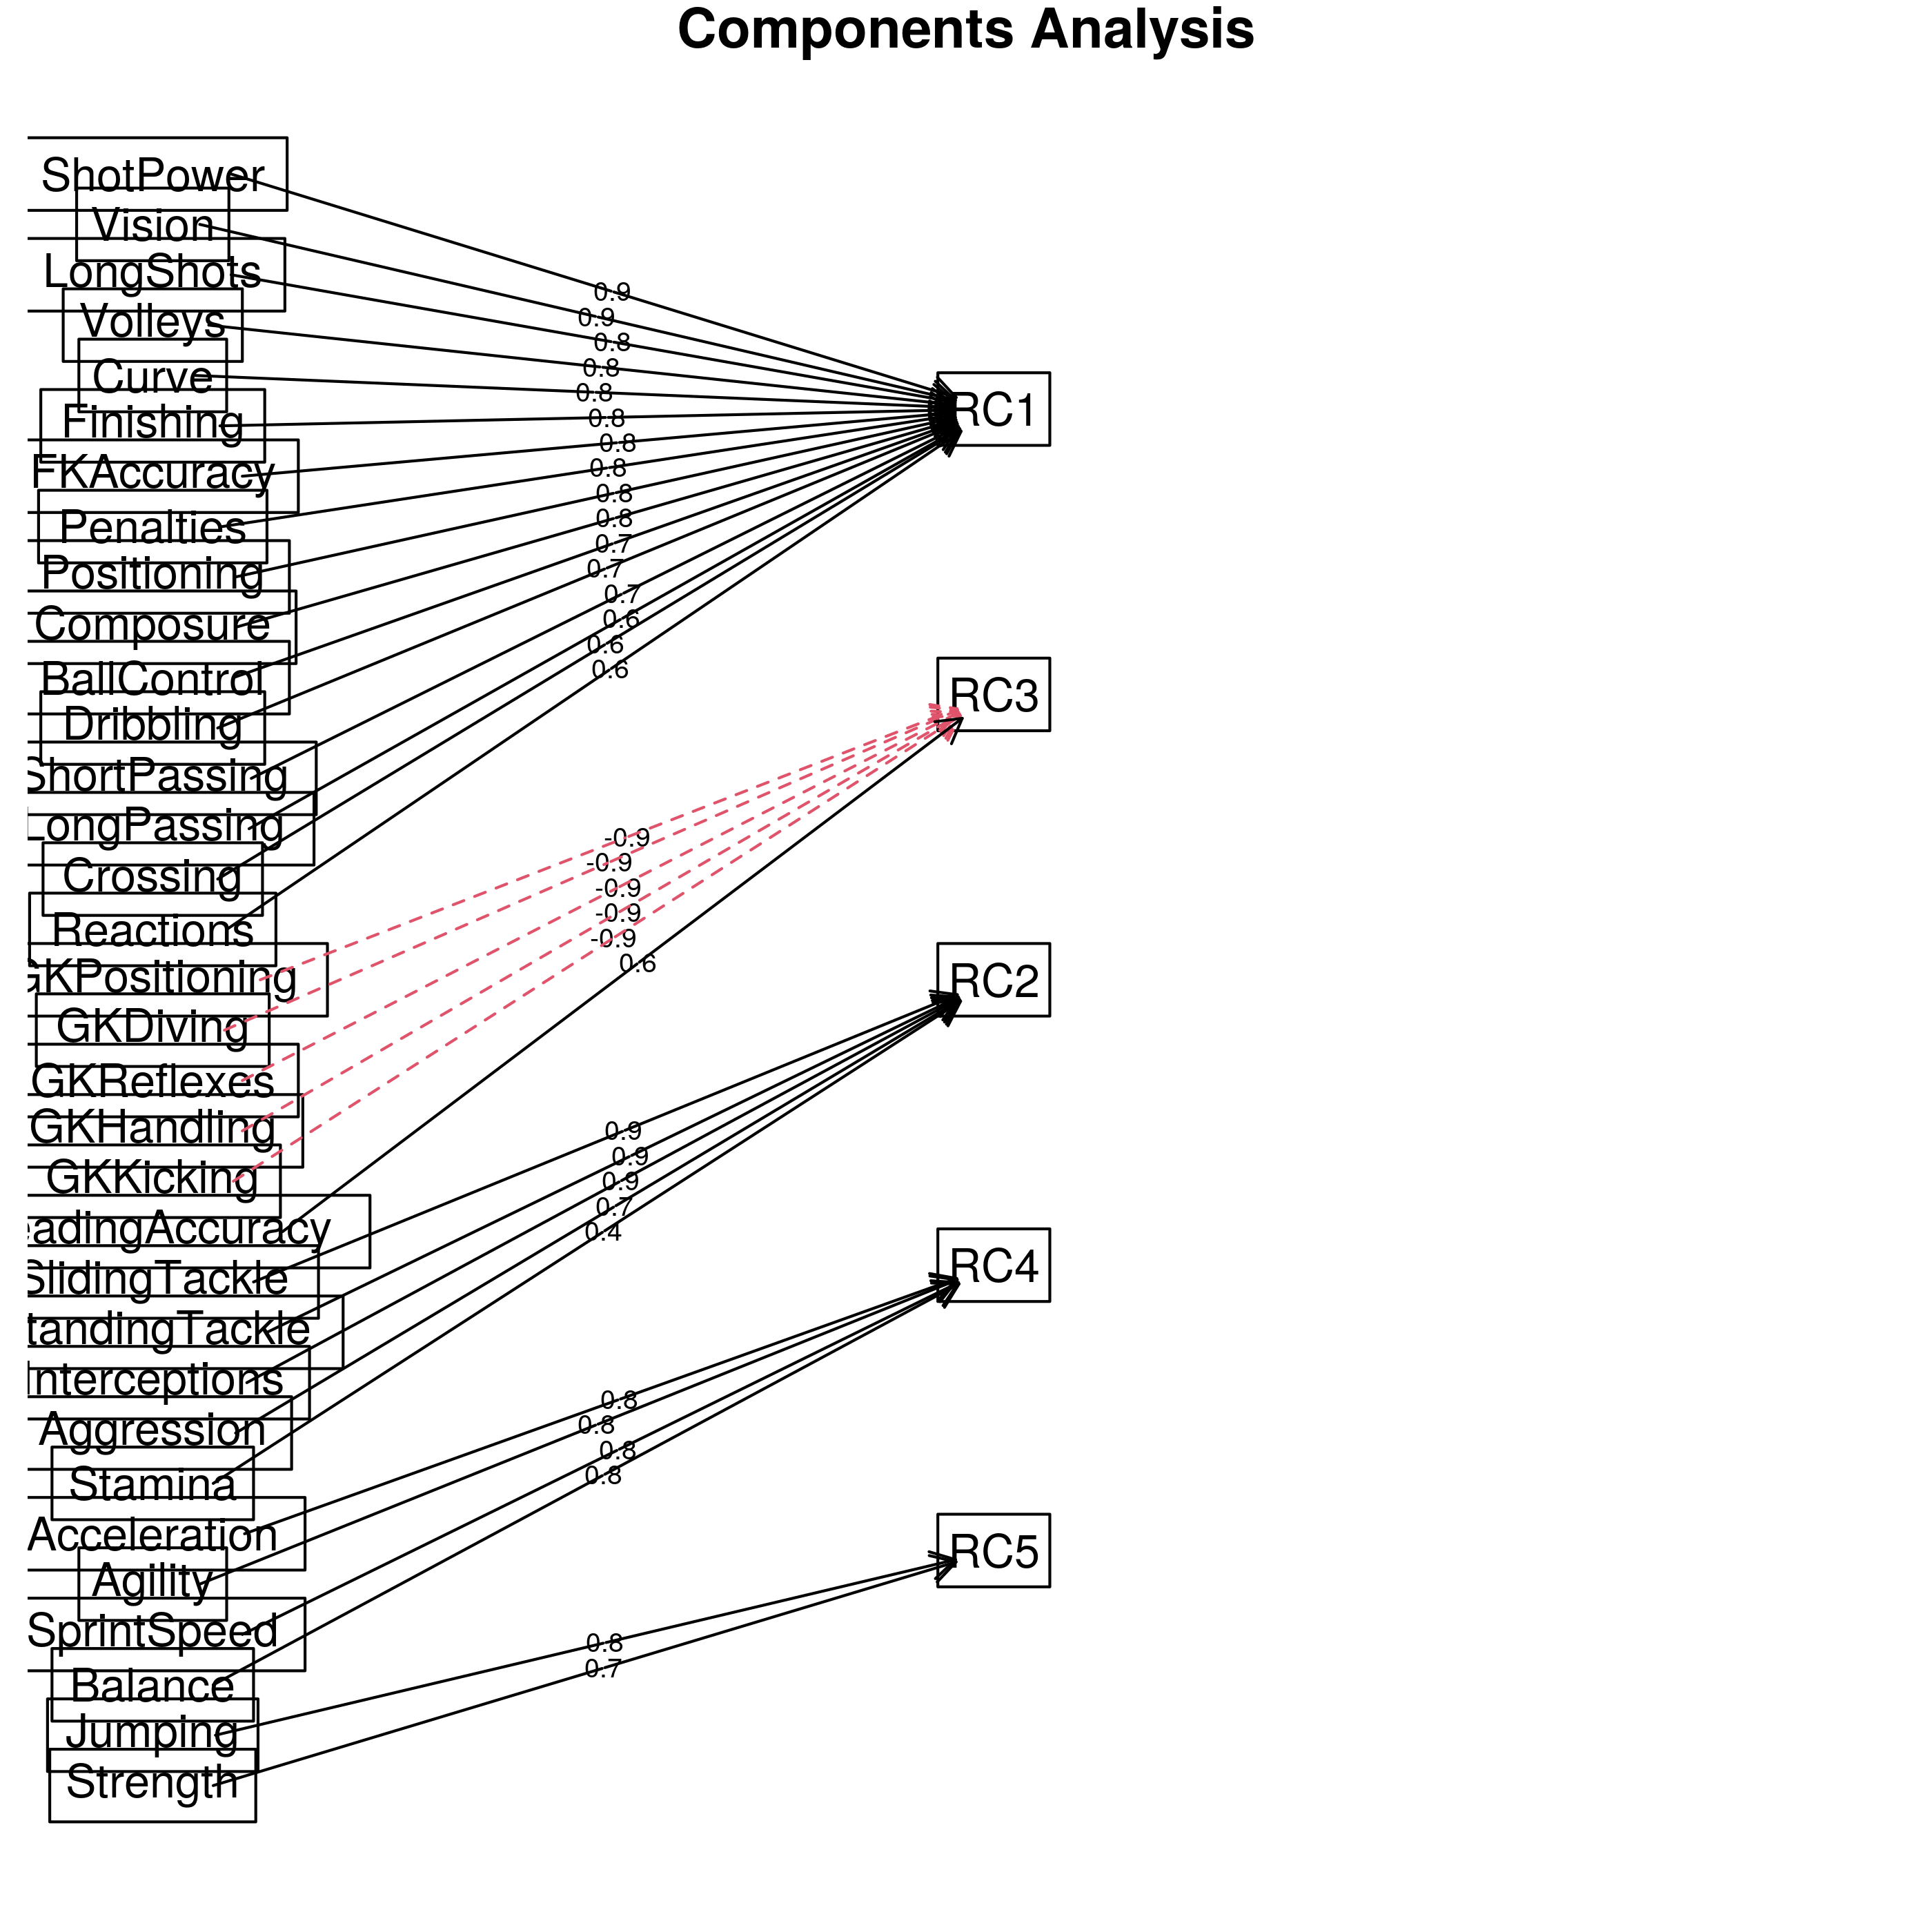

In [114]:
options(repr.plot.res=400)
fa.diagram(fifa_varimax)

### 행렬도 

`-` 아래는 Varimax를 이용하여 나타낸 행렬도이다. 

`-` RC3은 필드플레이어와 골키퍼를 구분하고 RC2는 수비형선수와 공격형선수를 구분하는 요인으로 해석할 수 있음을 알 수 있다. 

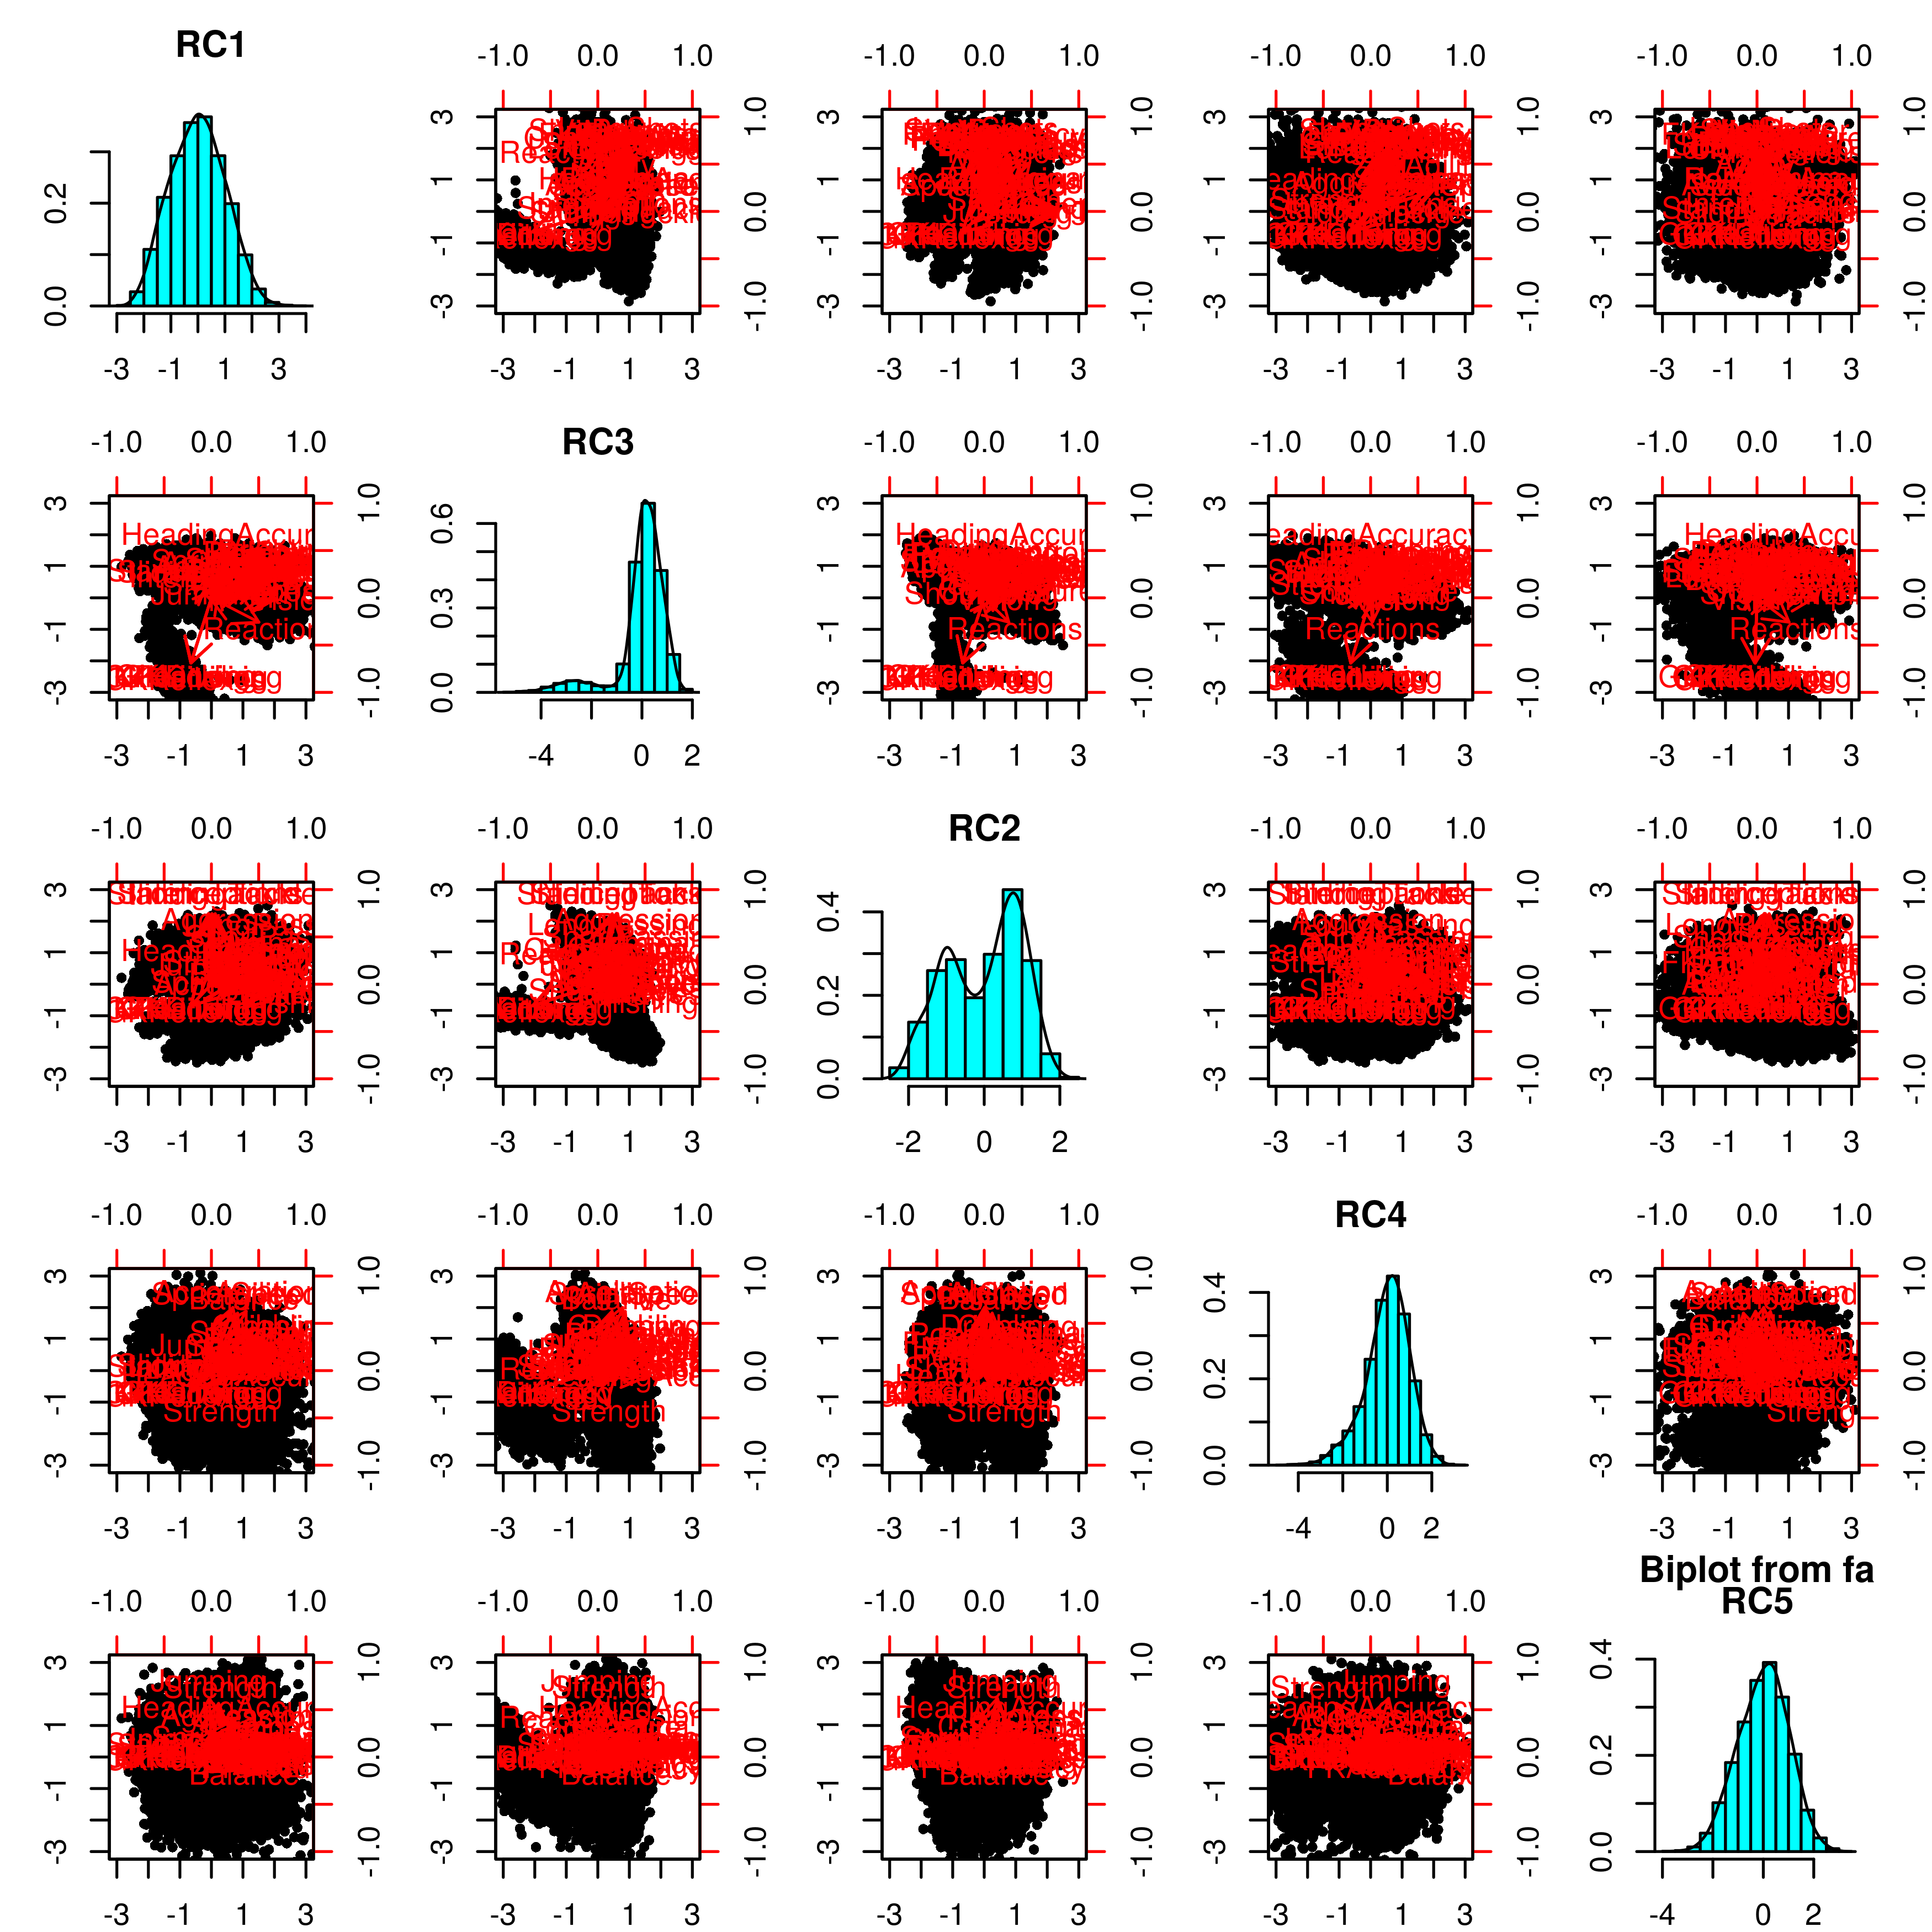

In [119]:
options(repr.plot.res=500)
biplot(fifa_varimax,cex=rep(par("cex"), 0.2))